This is a test implementation for the ID3 decision tree. If it works well, it will be moved to our implementations.py file. ID3 assumes all features are categorical, so we have to split numerical data into categories to make use of them.
October 25th: the notebook now contains ID3 + PCA + k-fold cross validation. The hyperparameters optimize for F1-score.

In [6]:
# Imports.
import sys
from implementations import *
import numpy as np
from helpers import *
from typing import List
from math import log2
from ID3 import *

In [7]:
# Input the data

# set hyperparams
k = 3 # bin size
max_depth = 10 # max ID3 tree depth
dim_cnt = 10 # max no of dimensions for PCA
#

path_to_dataset = "data/dataset"

x_train, x_test, y_train, train_ids, test_ids = load_csv_data(
    path_to_dataset, max_rows=15000, max_features=120, NaNstrat="fill"
) # loading is too slow, I use max_rows and max_features for testing -M

# I'm skipping preprocessing as I don't need to standardize when I'm going to split the numerical data into bins either way.
# Ideally I still remove 0-variance columns.
mask = x_train.std(axis=0) != 0
x_train = x_train[:, mask]
x_train = pca_reduction(x_train, dim_cnt)

# ID3 specific: convert the labels to strings
y_train = y_train[:].astype(str).reshape(-1, 1)
# Discretize numeric features
tx = x_train
bins = compute_bins(tx, k)
tx_disc = apply_bins(tx, bins)
x_test_disc = apply_bins(x_test, bins)



In [8]:
# Format the test data for the ID3 function
def ID3_format(x, y):
    dummy_header = np.array([f"col{i}" for i in range(x.shape[1])]) # we got rid of feature names in preprocess and I don't want to change that code so I assign some names here

    train_data = np.hstack((x, y)) # slap x and y together to comply to ID3 method's format
    return dummy_header, train_data


In [9]:
# This is the test implementation for kfold cross validation. If it works, it should be moved to helpers.py.

def kfold_inds(n_samples : int, k : int, seed=42):
    """
    Returns start and end indices of k folds on n_samples samples.
    Any remainder is added to the last fold.
    Returns: a list of pairs (2-element lists) of start and end indices respectively.
    """
    np.random.seed(seed)
    inds = []
    
    for i in range(k):
        inds.append([n_samples//k * i, n_samples//k * (i+1) - 1])
    inds[-1][1] = n_samples - 1 # add the rest to the last fold
    return inds



In [10]:
def metric(true_ys, predictions): 
    """
    The metric we use to decide which model hyperparameters we use. Currently, F1 score is implemented.
    """
    y_true = np.array(true_ys, dtype=int).ravel()
    y_pred = np.array(predictions, dtype=int).ravel()

    # Compute confusion terms
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == -1))
    fn = np.sum((y_pred == -1) & (y_true == 1))

    # Precision, recall, F1
    precision = tp / (tp + fp + 1e-10)
    recall = tp / (tp + fn + 1e-10)
    f1 = 2 * precision * recall / (precision + recall + 1e-10)

    return f1

In [11]:

# Train the model.
def test_hyperparams(x_train, y_train, max_depth: int, k=3, seed = 42):
    """
    max_depth - max depth of ID3 tree
    k - number of folds in k-fold cross validation 
    Returns: the depth of the best model. Ties are broken by returning the simplest model i.e. least depth.
    """
    assert len(x_train) == len(y_train)

    # permute the data randomly
    if seed is not None:
        np.random.seed(seed)
        perm = np.random.permutation(len(x_train))
        x_train = x_train[perm]
        y_train = y_train[perm]
    
    folds = kfold_inds(len(x_train), k)
    best_score = -1.0
    do_break = False
    
    for depth in range(1, max_depth + 1):
        print(f"Testing depth = {depth}")
        scores = []
        
        best_fold_score = -1.0

        for fold in folds:
            start, end = fold

            # Split into validation and training
            xi_test = x_train[start:end]
            yi_test = y_train[start:end]

            xi_train = np.concatenate((x_train[:start], x_train[end:]), axis=0)
            yi_train = np.concatenate((y_train[:start], y_train[end:]), axis=0)

            header, train_data = ID3_format(xi_train, yi_train)

            try:
                model = ID3()
                model.fit(header, train_data, depth, verbose=False)
    
                header_test, test_data = ID3_format(xi_test, yi_test)
                predictions = model.predict(header_test, test_data, verbose=False)

            except Exception as e:
                print("depth too large, interrupting...")
                do_break = True
                break
            score = metric(predictions, yi_test) 
            scores.append(score)
            
            if score > best_fold_score:
                best_fold_score = score
                best_fold_preds, true_ys = predictions, yi_test
        
        if do_break:
            break
        
        
        mean_acc = np.mean(scores)
        print(f"Mean F1-score (depth={depth}): {mean_acc:.4f}")

        if mean_acc > best_score:
            best_score = mean_acc
            best_depth = depth
            ### Generate confusion matrix
            y_true = np.array(true_ys, dtype=int).ravel()
            y_pred = np.array(best_fold_preds, dtype=int)
            cm = create_confusion_matrix(y_true, y_pred)
            
            ###

    print(f"\nBest depth = {best_depth} with mean F1-score = {best_score:.4f}")
    # display the best confusion matrix
    _ = cm_visualization(cm, f"depth = {depth}")
    return best_depth    

Testing depth = 1
Mean F1-score (depth=1): 0.5556
Testing depth = 2
Mean F1-score (depth=2): 0.2222
Testing depth = 3
Mean F1-score (depth=3): 0.2222
Testing depth = 4
Mean F1-score (depth=4): 0.2222
Testing depth = 5
Mean F1-score (depth=5): 0.2222
Testing depth = 6
Mean F1-score (depth=6): 0.2222
Testing depth = 7
Mean F1-score (depth=7): 0.2222
Testing depth = 8
Mean F1-score (depth=8): 0.2222
Testing depth = 9
Mean F1-score (depth=9): 0.2222
Testing depth = 10
Mean F1-score (depth=10): 0.2222

Best depth = 1 with mean F1-score = 0.5556


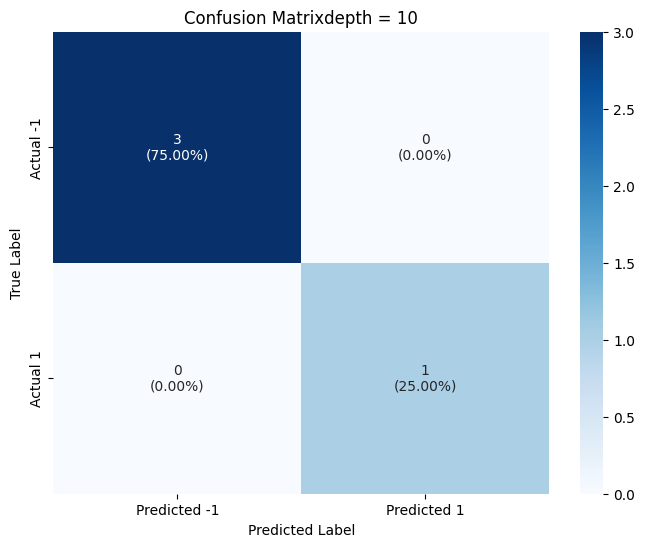

In [12]:
# Find out the best ID3 tree depth
# Experiments have shown the best depth is 1. Uncomment to see for yourself.
best_depth = test_hyperparams(tx_disc, y_train, max_depth)
# best_depth = 1

In [13]:
# Fit the best model we found
dummy_column = np.full((tx_disc.shape[0], 1), "x") # placeholder because ID3::predict expects a placeholder last column
final_header, final_train_data = ID3_format(tx_disc, y_train) 
best_model = ID3()
best_model.fit(final_header, final_train_data, best_depth)


In [11]:
# Generate predictions on it
x_test_disc = apply_bins(x_test, bins)
dummy_column_test = np.full((x_test_disc.shape[0], 1), "x")
test_header, test_data = ID3_format(x_test_disc, dummy_column_test)
predictions = best_model.predict(test_header, test_data)

In [12]:
print(predictions)


['-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1', '-1

Still much too slow to process the whole dataset.